# Flight Delay Analysis

## Objective

Analyze flight data to understand delay patterns.

In [1]:
# Import libraries
import pandas as pd

In [2]:
# Load dataset
df = pd.read_csv("flights.csv")

C:\Users\monas\AppData\Local\Temp\ipykernel_15476\3441919194.py:2: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("flights.csv")


In [4]:
# View first rows of the dataset
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Check structure, columns and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [6]:
# Check for missing values in each column
df.isnull().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

In [7]:
# Select only relevant columns for delay analysis
df_clean = df[[
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY"
]]

In [8]:
# View cleaned dataset (selected columns only)
df_clean.head()

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DEPARTURE_DELAY,ARRIVAL_DELAY
0,AS,ANC,SEA,-11.0,-22.0
1,AA,LAX,PBI,-8.0,-9.0
2,US,SFO,CLT,-2.0,5.0
3,AA,LAX,MIA,-5.0,-9.0
4,AS,SEA,ANC,-1.0,-21.0


In [9]:
# Check structure of cleaned dataset
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 5 columns):
 #   Column               Dtype  
---  ------               -----  
 0   AIRLINE              object 
 1   ORIGIN_AIRPORT       object 
 2   DESTINATION_AIRPORT  object 
 3   DEPARTURE_DELAY      float64
 4   ARRIVAL_DELAY        float64
dtypes: float64(2), object(3)
memory usage: 222.0+ MB


In [10]:
# Get basic statistics of numerical columns
df_clean.describe()

,DEPARTURE_DELAY,ARRIVAL_DELAY
count,5.732926e+06,5.714008e+06
mean,9.370158e+00,4.407057e+00
std,3.708094e+01,3.927130e+01
min,-8.200000e+01,-8.700000e+01
25%,-5.000000e+00,-1.300000e+01
50%,-2.000000e+00,-5.000000e+00
75%,7.000000e+00,8.000000e+00
max,1.988000e+03,1.971000e+03


In [11]:
# Check missing values after cleaning
df_clean.isnull().sum()

AIRLINE                     0
ORIGIN_AIRPORT              0
DESTINATION_AIRPORT         0
DEPARTURE_DELAY         86153
ARRIVAL_DELAY          105071
dtype: int64

## Missing Values Analysis

Delay-related columns contain missing values, which likely indicate flights without recorded delays rather than data errors.

In [13]:
# Average arrival delay per airline
result = df_clean.groupby("AIRLINE")["ARRIVAL_DELAY"].mean().sort_values(ascending=False)

result

AIRLINE
NK    14.471800
F9    12.504706
B6     6.677861
EV     6.585379
MQ     6.457873
OO     5.845652
UA     5.431594
VX     4.737706
WN     4.374964
US     3.706209
AA     3.451372
HA     2.023093
DL     0.186754
AS    -0.976563
Name: ARRIVAL_DELAY, dtype: float64

## Insight: Arrival Delays

We calculated the average arrival delay per airline and observed differences in performance.

Some airlines have negative average arrival delay, meaning they often arrive a bit earlier than scheduled.

This shows that “delay” here is really about deviation from schedule, not just late arrivals.

In [17]:
# Top 5 best airlines (lowest delay)
best = result.sort_values().head(5)

best

AIRLINE
AS   -0.976563
DL    0.186754
HA    2.023093
AA    3.451372
US    3.706209
Name: ARRIVAL_DELAY, dtype: float64

In [18]:
# Top 5 worst airlines (highest delay)
worst = result.sort_values(ascending=False).head(5)

worst

AIRLINE
NK    14.471800
F9    12.504706
B6     6.677861
EV     6.585379
MQ     6.457873
Name: ARRIVAL_DELAY, dtype: float64

In [19]:
combined = pd.concat([best, worst])

Text(0, 0.5, 'Average Arrival Delay (minutes)')

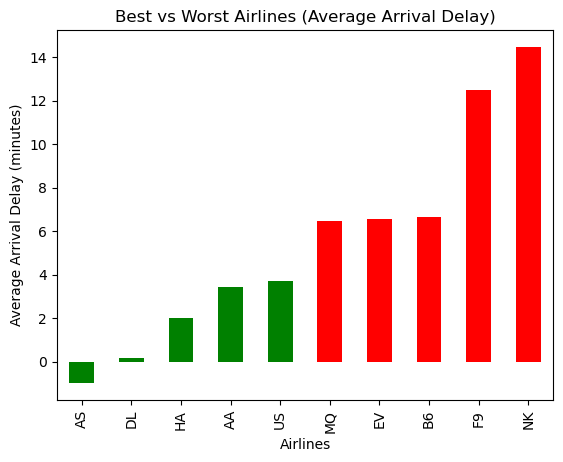

In [29]:
# Visual comparison of best vs worst airlines
ax = combined.sort_values().plot(
    kind="bar",
    color=["green"]*5 + ["red"]*5,
    title="Best vs Worst Airlines (Average Arrival Delay)"
)

ax.set_xlabel("Airlines")
ax.set_ylabel("Average Arrival Delay (minutes)")

## Insight

The visualization highlights a clear gap between the best and worst performing airlines in terms of average arrival delay, making the differences in operational performance easy to compare.